In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# load the dataset
df = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (6362620, 11)

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
#fraud distribution
fraud_counts = df['isFraud'].value_counts()
fraud_percentage = df['isFraud'].value_counts(normalize=True) * 100

print("Transaction counts:")
print(f"  Legitimate: {fraud_counts[0]:,}")
print(f"  Fraudulent: {fraud_counts[1]:,}")
print(f"\nAs percentage:")
print(f"  Legitimate: {fraud_percentage[0]:.4f}%")
print(f"  Fraudulent: {fraud_percentage[1]:.4f}%")

Transaction counts:
  Legitimate: 6,354,407
  Fraudulent: 8,213

As percentage:
  Legitimate: 99.8709%
  Fraudulent: 0.1291%


In [9]:
#transaction types
print("Transaction type distribution:")
print(df['type'].value_counts())
print("\nFraud by transaction type:")
print(df.groupby('type')['isFraud'].sum().sort_values(ascending=False))

Transaction type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud by transaction type:
type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64


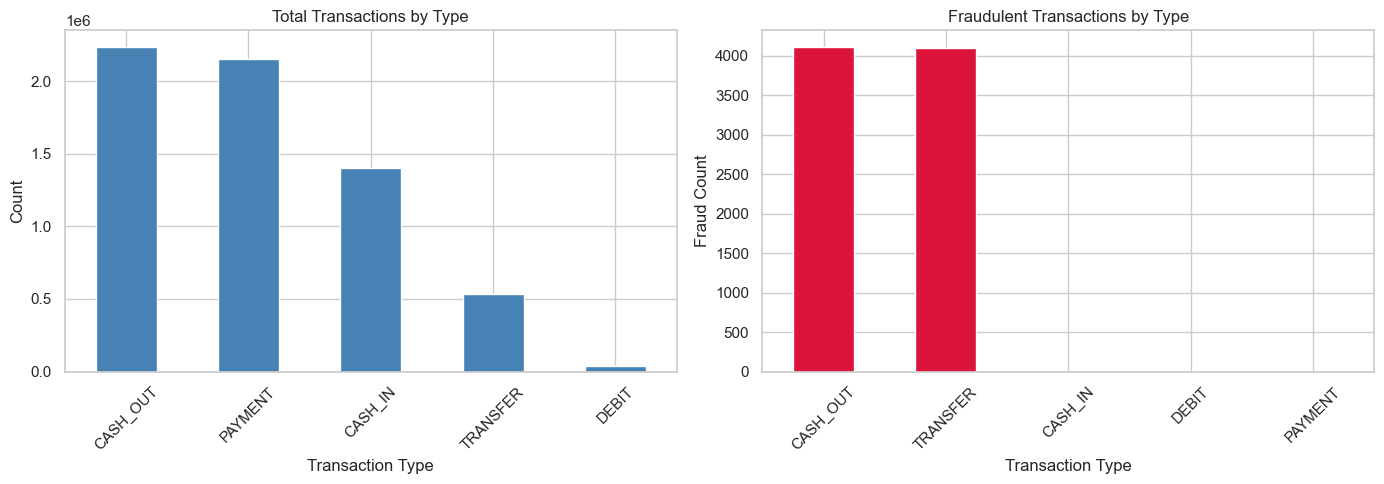

Plot saved ✓


In [10]:
#visualizing fraud by transaction type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — total transactions by type
df['type'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Total Transactions by Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 — fraud count by transaction type
df.groupby('type')['isFraud'].sum().sort_values(ascending=False).plot(
    kind='bar',
    ax=axes[1],
    color='crimson',
    edgecolor='white'
)
axes[1].set_title('Fraudulent Transactions by Type')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Fraud Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved ✓")

In [11]:
#isolate only TRANSFER and CASH_OUT
df_fraud = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

print(f"Rows after filtering: {df_fraud.shape[0]:,}")
print(f"Fraud cases remaining: {df_fraud['isFraud'].sum():,}")
print(f"\nFraud rate in filtered data:")
print(f"  {df_fraud['isFraud'].mean() * 100:.4f}%")

Rows after filtering: 2,770,409
Fraud cases remaining: 8,213

Fraud rate in filtered data:
  0.2965%


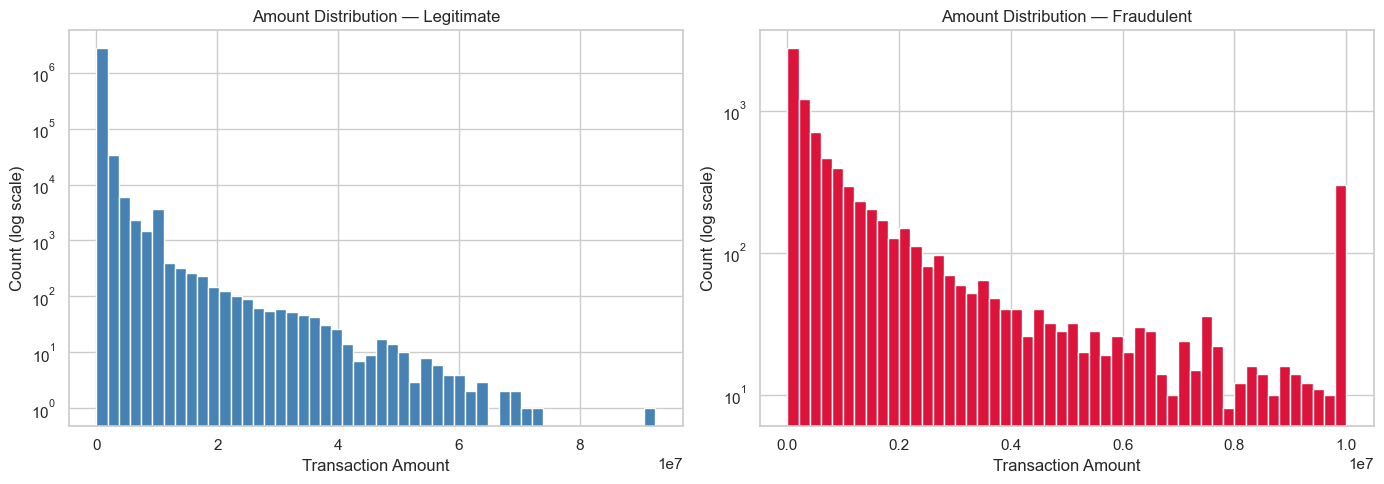

Plot saved ✓


In [12]:
#transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — amount distribution for legitimate transactions
axes[0].hist(
    df_fraud[df_fraud['isFraud'] == 0]['amount'],
    bins=50,
    color='steelblue',
    edgecolor='white',
    log=True
)
axes[0].set_title('Amount Distribution — Legitimate')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Count (log scale)')

# Plot 2 — amount distribution for fraudulent transactions
axes[1].hist(
    df_fraud[df_fraud['isFraud'] == 1]['amount'],
    bins=50,
    color='crimson',
    edgecolor='white',
    log=True
)
axes[1].set_title('Amount Distribution — Fraudulent')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Count (log scale)')

plt.tight_layout()
plt.savefig('../notebooks/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved ✓")

In [13]:
#amount statistics
print("Legitimate transaction amounts:")
print(df_fraud[df_fraud['isFraud'] == 0]['amount'].describe())

print("\nFraudulent transaction amounts:")
print(df_fraud[df_fraud['isFraud'] == 1]['amount'].describe())

Legitimate transaction amounts:
count    2.762196e+06
mean     3.141155e+05
std      8.771441e+05
min      1.000000e-02
25%      8.290823e+04
50%      1.710345e+05
75%      3.059942e+05
max      9.244552e+07
Name: amount, dtype: float64

Fraudulent transaction amounts:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


In [14]:
# balance discrepancy analysis
# For legitimate transactions, newbalanceOrig should equal oldbalanceOrg - amount
# Let's check if this holds for fraud vs legitimate

df_fraud = df_fraud.copy()

# calculate expected new balance vs actual new balance
df_fraud['balance_discrepancy'] = (
    df_fraud['oldbalanceOrg'] - 
    df_fraud['amount'] - 
    df_fraud['newbalanceOrig']
).abs()

print("Balance discrepancy — Legitimate:")
print(df_fraud[df_fraud['isFraud']==0]['balance_discrepancy'].describe())

print("\nBalance discrepancy — Fraudulent:")
print(df_fraud[df_fraud['isFraud']==1]['balance_discrepancy'].describe())

Balance discrepancy — Legitimate:
count    2.762196e+06
mean     2.868035e+05
std      8.763752e+05
min      0.000000e+00
25%      5.261343e+04
50%      1.442008e+05
75%      2.804663e+05
max      9.244552e+07
Name: balance_discrepancy, dtype: float64

Balance discrepancy — Fraudulent:
count    8.213000e+03
mean     1.069233e+04
std      2.651461e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+07
Name: balance_discrepancy, dtype: float64


In [15]:
# zero balance after transaction
print("Sender balance is zero after transaction:\n")

legitimate_zero = (df_fraud[df_fraud['isFraud']==0]['newbalanceOrig'] == 0).mean() * 100
fraud_zero = (df_fraud[df_fraud['isFraud']==1]['newbalanceOrig'] == 0).mean() * 100

print(f"  Legitimate transactions: {legitimate_zero:.2f}%")
print(f"  Fraudulent transactions: {fraud_zero:.2f}%")

Sender balance is zero after transaction:

  Legitimate transactions: 90.10%
  Fraudulent transactions: 98.05%


In [16]:
# destination account analysis
print("Destination account had zero balance before receiving:\n")

legit_dest_zero = (df_fraud[df_fraud['isFraud']==0]['oldbalanceDest'] == 0).mean() * 100
fraud_dest_zero = (df_fraud[df_fraud['isFraud']==1]['oldbalanceDest'] == 0).mean() * 100

print(f"  Legitimate transactions: {legit_dest_zero:.2f}%")
print(f"  Fraudulent transactions: {fraud_dest_zero:.2f}%")

print("\nDestination account balance after transaction:\n")
print("Legitimate:")
print(df_fraud[df_fraud['isFraud']==0]['newbalanceDest'].describe())
print("\nFraudulent:")
print(df_fraud[df_fraud['isFraud']==1]['newbalanceDest'].describe())

Destination account had zero balance before receiving:

  Legitimate transactions: 13.90%
  Fraudulent transactions: 65.15%

Destination account balance after transaction:

Legitimate:
count    2.762196e+06
mean     2.052024e+06
std      4.678898e+06
min      0.000000e+00
25%      3.287964e+05
50%      8.299029e+05
75%      2.124570e+06
max      3.561793e+08
Name: newbalanceDest, dtype: float64

Fraudulent:
count    8.213000e+03
mean     1.279708e+06
std      3.908817e+06
min      0.000000e+00
25%      0.000000e+00
50%      4.676420e+03
75%      1.058725e+06
max      2.367265e+08
Name: newbalanceDest, dtype: float64


In [17]:
# EDA summary
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"\n1. Dataset: {df.shape[0]:,} total transactions")
print(f"2. Fraud rate: 0.13% ({df['isFraud'].sum():,} cases)")
print(f"3. Fraud ONLY occurs in TRANSFER and CASH_OUT")
print(f"4. Fraud transactions are 4.7x larger on average")
print(f"   Legitimate mean: 314,000")
print(f"   Fraudulent mean: 1,467,000")
print(f"5. 65% of fraud goes to zero-balance destination")
print(f"   vs only 13.9% for legitimate transactions")
print(f"\nKey features identified:")
print(f"  - type (TRANSFER vs CASH_OUT)")
print(f"  - amount")
print(f"  - oldbalanceDest (mule account signal)")
print(f"  - oldbalanceOrg")
print(f"  - newbalanceOrig")
print("=" * 50)

EDA SUMMARY

1. Dataset: 6,362,620 total transactions
2. Fraud rate: 0.13% (8,213 cases)
3. Fraud ONLY occurs in TRANSFER and CASH_OUT
4. Fraud transactions are 4.7x larger on average
   Legitimate mean: 314,000
   Fraudulent mean: 1,467,000
5. 65% of fraud goes to zero-balance destination
   vs only 13.9% for legitimate transactions

Key features identified:
  - type (TRANSFER vs CASH_OUT)
  - amount
  - oldbalanceDest (mule account signal)
  - oldbalanceOrg
  - newbalanceOrig
